# SVM - Máquinas de vetores de suporte

É um método de aprendizado de máquina utilizado para classificar informações. Ele funciona procurando uma forma de separar diferentes grupos de dados. Imagine que temos pontos de duas cores em um gráfico, representando duas categorias. O SVM tenta encontrar uma linha (ou um plano, se os dados forem mais complexos) que consiga dividir esses grupos da melhor maneira possível. 

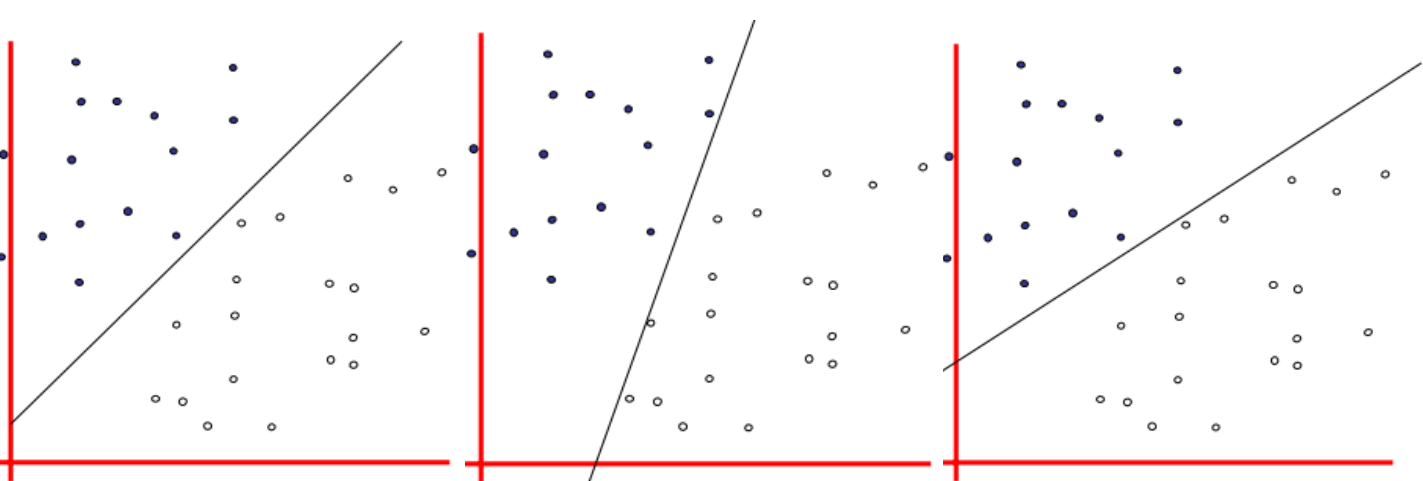

A ideia principal é escolher a linha que fique o mais distante possível dos pontos dos dois grupos, criando uma espécie de “zona de segurança”. Isso ajuda o modelo a tomar decisões mais confiáveis quando receber novos dados para classificar.

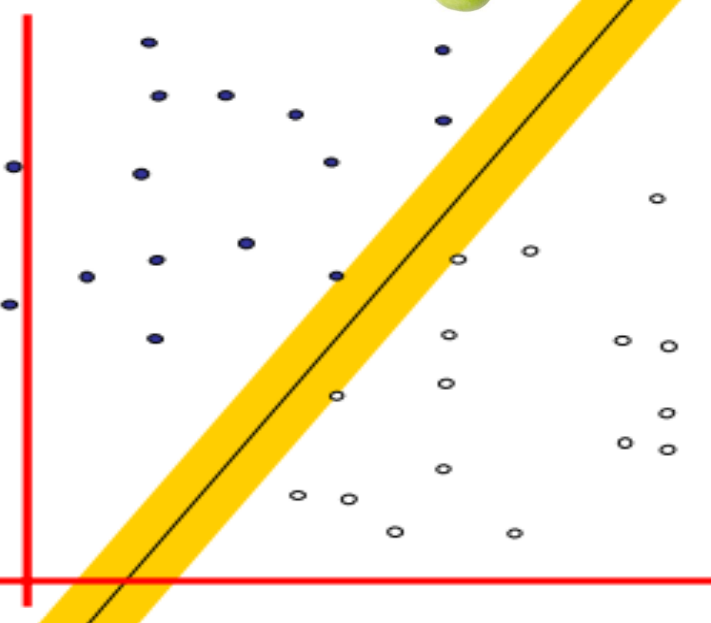

Os pontos circulados em vermelho, marcados com SV, são chamados de Vetores de Suporte. Eles são os pontos mais próximos do hiperplano, um de cada classe. 
Esses pontos são fundamentais, porque eles definem a posição da linha verde, se você movesse ou tirasse qualquer outro ponto que não seja SV, a linha não mudaria, mas movendo esses pontos, o hiperplano muda, ou seja, somente esses pontos realmente "determinam" a separação.

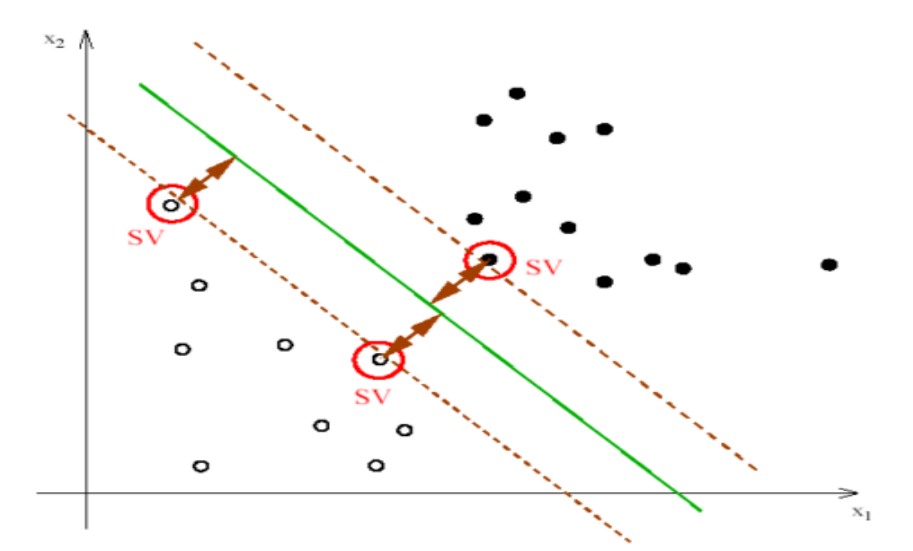

## Convex hull

Uma técnica utilizada no SVM para separar os conjuntos, é como se esticasse um elástico ao redor dos pontos de cada grupo. O elástico forma uma forma geométrica que envolve todos eles. Na imagem abaixo, o grupo dos quadrados tem seu "elástico" contornando os pontos. O grupo dos círculos também tem o seu contorno. Esses contornos são chamados de convex hulls.O SVM ignora os pontos internos e usa apenas os pontos da borda. A linha (hiperplano) é posicionada entre as duas envoltórias convexas. Os pontos na borda são os vetores de suporte — fundamentais para o modelo.


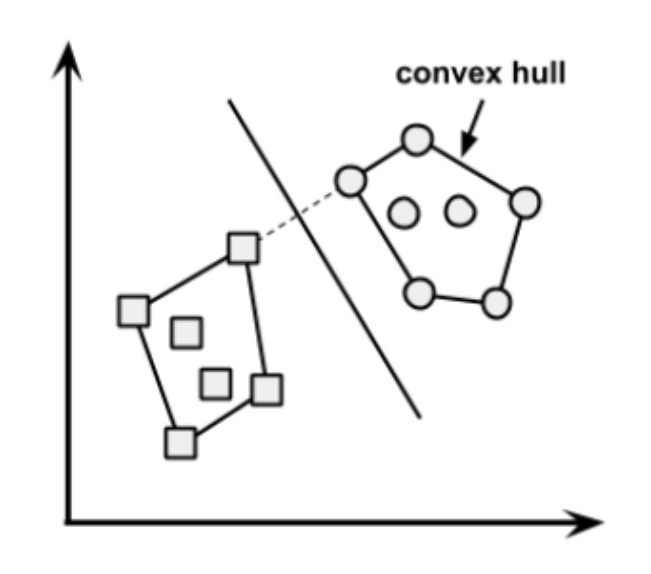

## Erros e custo

No SVM precisamos determinar dois parâmetros um deles é o C que pune as classificações incorretas do algoritmo, isso faz o modelo ser mais rígido, mas também pode se ajustar demais aos dados (overfitting).

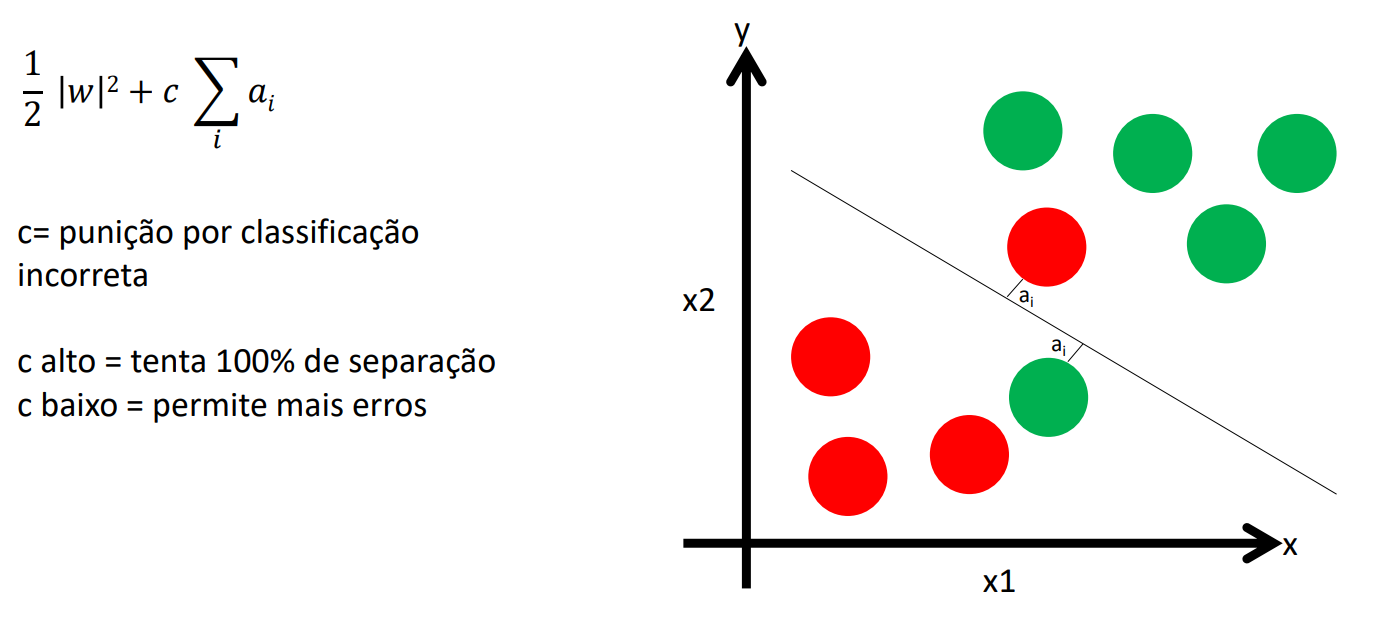

## Kernel Trick

Outro parâmetro é o kernel, às vezes, os dados não podem ser separados por uma linha reta, assim, o SVM usa o kernel para transformar os dados para outra dimensão, onde fica possível separar. Como no exemplo abaixo não é possível traçar uma reta e separar os dois grupos assim elevamos todos os valores e consiguimos separa-los.

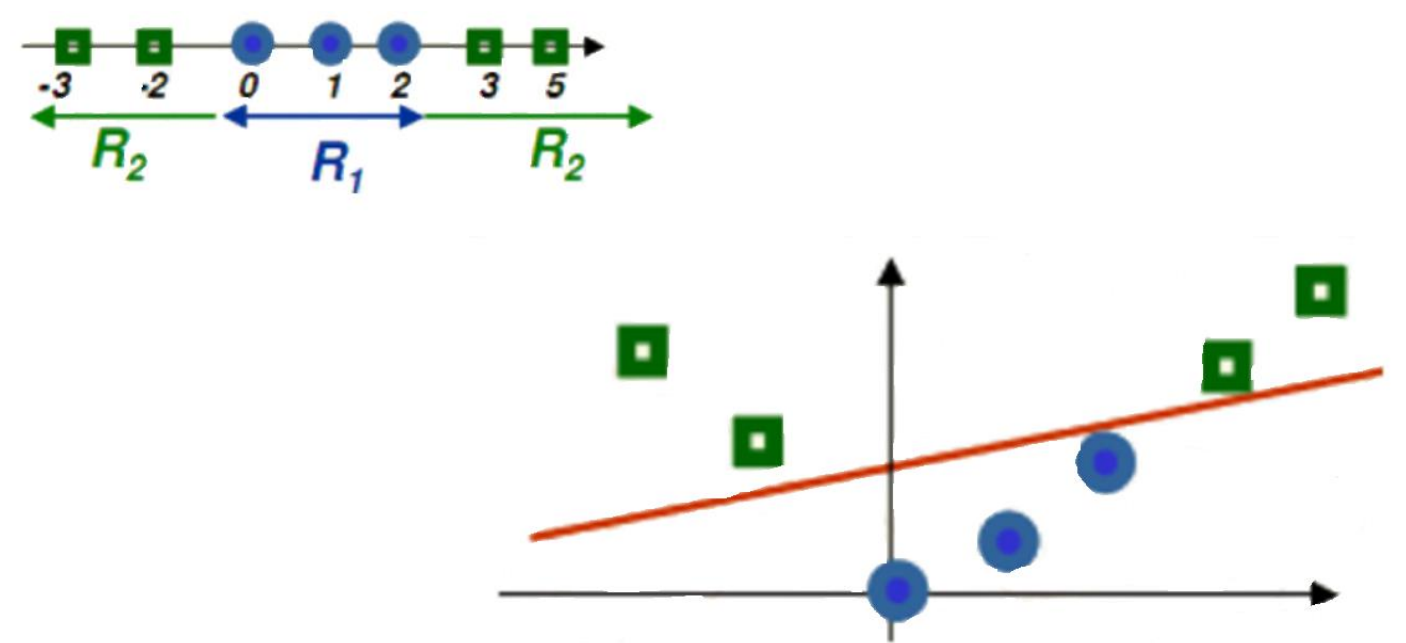

Existem diferentes tipos de kernel:

**Kernel Linear**

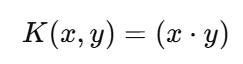

Não transforma os dados, serve quando os dados já são separáveis por uma linha, é o mais simples e mais rápido.

**Kernel polinomial**

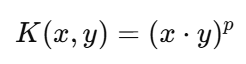

Permite criar fronteiras curvas, controladas pelo grau 𝑝, quanto maior o grau, mais complexa a curva.

**Kernel Gaussiano (RBF / Radial)**

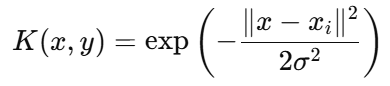

Cria regiões arredondadas ao redor dos pontos, permite o SVM desenhar curvas complexas, muito usado quando a fronteira não é linear.

**Kernel Tangente Hiperbólica (Sigmoid)**

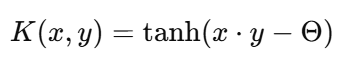

Funciona de forma parecida com um neurônio de rede neural, pode criar curvas mais suaves.

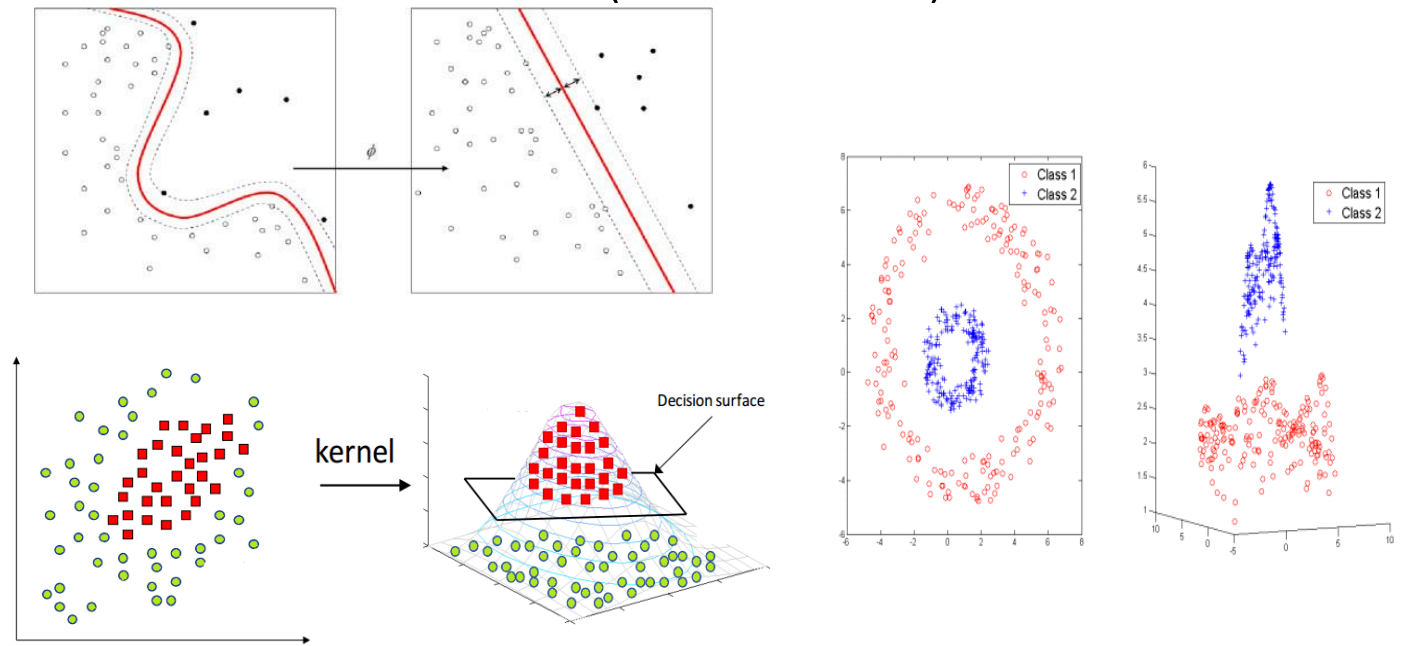

O algoritmo pode criar novas dimensões nos dados para conseguir a melhor separação. Slack variables permitem alguns erros e ajudam o modelo a ser mais flexível no mundo real.

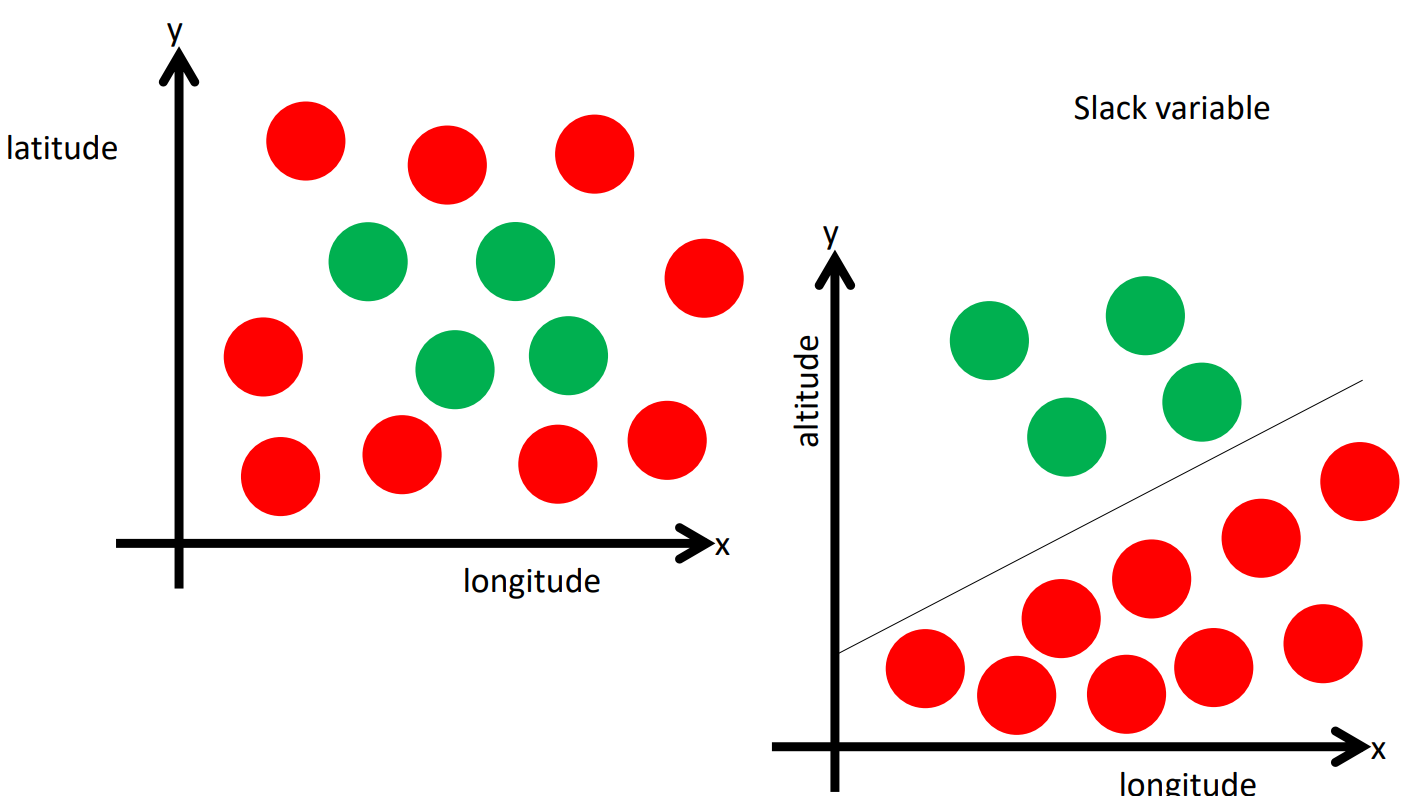

**Vantagens**

• Não é muito influenciado por ruídos nos dados

• Utilizado para classificação e regressão

• Aprende conceitos não presentes nos dados originais

• Mais fácil de usar do que redes neurais

**Desvantagens**

• Testar várias combinações de parâmetros

• Lento

• Black box


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
base_credit = pd.read_csv('credit_data.csv')
base_credit

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
...,...,...,...,...,...
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0


In [3]:
np.unique(base_credit['default'], return_counts=True)

(array([0, 1]), array([1717,  283]))

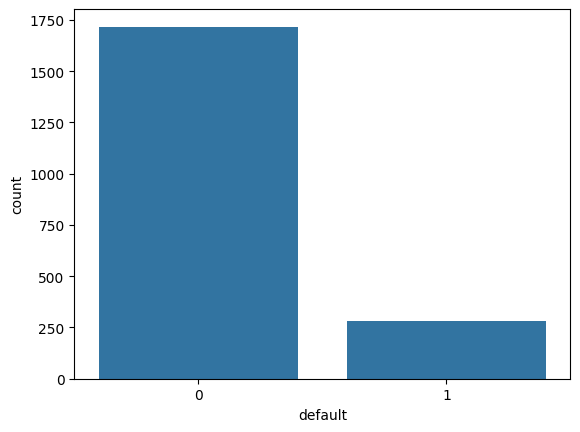

In [4]:
sns.countplot(x = base_credit['default']);

In [5]:
base_credit['age'][base_credit['age'] > 0].mean()

np.float64(40.92770044906149)

In [6]:
base_credit.loc[base_credit['age'] < 0, 'age'] = 40.92

In [7]:
base_credit.isnull().sum()

clientid    0
income      0
age         3
loan        0
default     0
dtype: int64

In [8]:
base_credit['age']=base_credit['age'].fillna(base_credit['age'].mean())

In [9]:
base_credit.isnull().sum()

clientid    0
income      0
age         0
loan        0
default     0
dtype: int64

In [10]:
X_credit = base_credit.iloc[:, 1:4].values
y_credit = base_credit.iloc[:, 4].values

In [11]:
from sklearn.preprocessing import StandardScaler
scaler_credit = StandardScaler()
X_credit = scaler_credit.fit_transform(X_credit)

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_credit_treinamento, X_credit_teste, y_credit_treinamento, y_credit_teste = train_test_split(X_credit, y_credit, test_size = 0.25, random_state = 0)

In [14]:
X_credit_treinamento.shape, y_credit_treinamento.shape

((1500, 3), (1500,))

In [15]:
X_credit_teste.shape, y_credit_teste.shape

((500, 3), (500,))

In [16]:
from sklearn.svm import SVC
svm_credit = SVC(kernel='rbf', C = 2)
svm_credit.fit(X_credit_treinamento, y_credit_treinamento)

,C,2
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [17]:
previsoes = svm_credit.predict(X_credit_teste)

In [18]:
from sklearn.metrics import accuracy_score, classification_report
accuracy_score(y_credit_teste, previsoes)

0.988

0.988

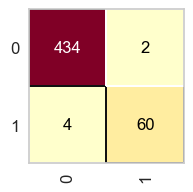

In [19]:
from yellowbrick.classifier import ConfusionMatrix
plt.figure(figsize=(2,2))
cm = ConfusionMatrix(svm_credit)
cm.fit(X_credit_treinamento, y_credit_treinamento)
cm.score(X_credit_teste, y_credit_teste)

# Exercício

Com base no dataset base_segundo_encontro, faça previsões se haverá um segundo encontro com base em entradas do usuário.

**Descrição do dados**

| Coluna                | Descrição                                       |
| --------------------- | ----------------------------------------------- |
| `tempo_conversa_min`  | Duração do encontro em minutos                  |
| `risadas`             | Quantidade de risadas no encontro               |
| `pontos_comuns`       | Quantidade de interesses em comum identificados |
| `nivel_timidez`       | Nível de timidez (0–10)                         |
| `mensagens_antes`     | Quantidade de mensagens trocadas antes          |
| `iniciativa_conversa` | Quem sustentou o papo (0–10)                    |
| `local_encontro`      | Café / Restaurante / Parque / Bar               |
| `momento_da_vida`     | Estável / Estressado / Cansado                  |
| `segundo_encontro`    | **Target** → **Sim** ou **Não**                 |

- Importe o dataset
- Separe os dados de treino e teste
- Aplique One-Hot Encolding nas variáveis categóricas
- Aplique padronização dos dados (StandardScaler)
- Receba entradas dos usuário fazendo perguntas sobre cada features indicando o tipo de resposta de precisa (de 0 a 10, por categoria, etc)
- Treine com todos os kernels e valores diferentes de C(0.1,1,2,10)
- Compare os resultados automaticamente
- Responda ao usuário se ele terá ou não um segundo encontro

## Solução

In [20]:
df = pd.read_csv("base_segundo_encontro.csv", sep=";", encoding="latin-1")
df.head()

,tempo_conversa_min,risadas,pontos_comuns,nivel_timidez,mensagens_antes,iniciativa_conversa,local_encontro,momento_da_vida,segundo_encontro
0,112,16,6,0,45,8,Restaurante,Estressado,Sim
1,102,13,2,10,41,6,Bar,Estável,Sim
2,24,8,2,3,16,9,Café,Estável,Sim
3,116,7,4,0,8,4,Bar,Estressado,Sim
4,81,1,2,5,5,7,Parque,Estável,Não


In [21]:
X = df.drop("segundo_encontro", axis=1)
y = df["segundo_encontro"]

In [22]:
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

onehot = ColumnTransformer(
    transformers=[('OneHot', OneHotEncoder(drop='first'), cat_cols)],
    remainder='passthrough'
)

X_encoded = onehot.fit_transform(X)

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.25, random_state=42)

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
kernels = ["linear", "rbf", "poly","sigmoid"]
C_values = [0.1, 1, 2, 10]

resultados = {}

for k in kernels:
    for c in C_values:
        model = SVC(kernel=k, C=c)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)
        resultados[(k, c)] = acc

resultados

{('linear', 0.1): 0.98,
 ('linear', 1): 0.996,
 ('linear', 2): 0.996,
 ('linear', 10): 0.996,
 ('rbf', 0.1): 0.784,
 ('rbf', 1): 0.956,
 ('rbf', 2): 0.964,
 ('rbf', 10): 0.944,
 ('poly', 0.1): 0.752,
 ('poly', 1): 0.896,
 ('poly', 2): 0.908,
 ('poly', 10): 0.928,
 ('sigmoid', 0.1): 0.9,
 ('sigmoid', 1): 0.968,
 ('sigmoid', 2): 0.972,
 ('sigmoid', 10): 0.968}

In [27]:
best = max(resultados, key=resultados.get)
best_kernel, best_C = best

print("Melhor kernel:", best_kernel)
print("Melhor C:", best_C)
print("Acurácia:", resultados[best])

Melhor kernel: linear
Melhor C: 1
Acurácia: 0.996


In [28]:
best_model = SVC(kernel=best_kernel, C=best_C)
best_model.fit(X_train, y_train)

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [31]:
def prever():
    print("\nResponda:")
    tempo = int(input("Tempo de conversa (min): "))
    risos = int(input("Quantidade de risadas: "))
    comuns = int(input("Pontos em comum (0-10): "))
    timidez = int(input("Nível de timidez (0-10): "))
    msgs = int(input("Mensagens antes do encontro: "))
    iniciativa = int(input("Iniciativa na conversa (0-10): "))
    local = input("Local (Café, Restaurante, Parque, Bar): ")
    momento = input("Momento da vida (Estável, Estressado, Cansado): ")
    
    entrada = pd.DataFrame([[tempo, risos, comuns, timidez, msgs, iniciativa, local, momento]], 
                           columns=["tempo_conversa_min","risadas","pontos_comuns","nivel_timidez","mensagens_antes","iniciativa_conversa","local_encontro","momento_da_vida"])
    
    entrada_encoded = onehot.transform(entrada)
    entrada_encoded = pd.DataFrame(entrada_encoded, columns=onehot.get_feature_names_out())
    entrada_scaled = scaler.transform(entrada_encoded)

    pred = best_model.predict(entrada_scaled)[0]
    print("\n Terá segundo encontro?:", pred)

In [32]:
prever()


Responda:


Tempo de conversa (min):  120
Quantidade de risadas:  1
Pontos em comum (0-10):  4
Nível de timidez (0-10):  2
Mensagens antes do encontro:  200
Iniciativa na conversa (0-10):  0
Local (Café, Restaurante, Parque, Bar):  Café
Momento da vida (Estável, Estressado, Cansado):  Estável



 Terá segundo encontro?: Sim


C:\Users\liq1ct\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
